In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [81]:
data = pd.read_csv("dataset\Twcs.csv")
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [82]:
data = data[data['inbound']==True]
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,"11,13,14",15.0


In [83]:
data = data.sample(n=10000, random_state=42)

In [84]:
data = data['text']

In [85]:
data.info()

<class 'pandas.Series'>
Index: 10000 entries, 26861 to 2337842
Series name: text
Non-Null Count  Dtype
--------------  -----
10000 non-null  str  
dtypes: str(1)
memory usage: 156.2 KB


In [86]:
data = data.reset_index(drop=True)

In [87]:
data.info()

<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: text
Non-Null Count  Dtype
--------------  -----
10000 non-null  str  
dtypes: str(1)
memory usage: 78.3 KB


## Text preprocessing

In [88]:
import re
import string
import nltk

In [89]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhard\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bhard\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bhard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [90]:
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [91]:
def clean(tweet):
    tweet1 = re.sub(r"^@\w+",'',tweet)
    tweet1 = re.sub(r'[#?.,$@]', '', tweet1)
    tweet1 = re.sub(r'\d+', '', tweet1)
    tweet1 = re.sub(r'\s+', ' ', tweet1).strip()
    tweet1 = re.sub(r'https?://\S+', '', tweet1)

    return tweet1


In [92]:
text_list = data.tolist()
text_list[:5]

['@AppleSupport Basically for a chat to be opened from call log, the message app should be opened/running in background. Otherwise, it takes twice.',
 '@AppleSupport iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, notif. off/on does not help. What to do? https://t.co/Jd98V9OvIu',
 'Dear god not again,@AppleSupport https://t.co/5Zf0Mnd6SI',
 '@ATVIAssist Hi there! If I buy Call of Duty WWII on steam today, do I have instant access to the open beta multiplayer?',
 "Hi @Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable"]

In [93]:
clean_tweet = [clean(tweet) for tweet in text_list]

In [94]:
clean_tweet[:5]

['Basically for a chat to be opened from call log the message app should be opened/running in background Otherwise it takes twice',
 'iOS and Watchos: No icon for Twitter notifications Restart of iphone/watch notif off/on does not help What to do ',
 'Dear god not againAppleSupport ',
 'Hi there! If I buy Call of Duty WWII on steam today do I have instant access to the open beta multiplayer',
 "Hi Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable"]

In [95]:
!pip install langid


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [96]:
import langid

def is_english(text):

    lang, score = langid.classify(text)

    return lang == 'en'

In [97]:
clean_tweet = [tweet for tweet in clean_tweet if is_english(tweet)]

In [98]:
stop_words = set(stopwords.words('english'))
neg_words = {'no', 'not', 'nor', 'neither', 'never', 'none'}
stop_words = stop_words - neg_words

In [99]:
wn = WordNetLemmatizer()
tk = TweetTokenizer(preserve_case=False,reduce_len=True,strip_handles=True)

In [100]:
corpus = []

In [101]:
def preprocess(tweet):
    tokens = tk.tokenize(tweet)
    temp = []

    for token in tokens:
        if token not in stop_words and token not in string.punctuation:
            lw = wn.lemmatize(token)
            lw = lw.lower()
            temp.append(lw)
    corpus.append(temp)

In [102]:
for tweet in clean_tweet:
    preprocess(tweet)

In [103]:
corpus = [sent for sent in corpus if len(sent) >= 3]

In [104]:
corpus

[['basically',
  'chat',
  'opened',
  'call',
  'log',
  'message',
  'app',
  'opened',
  'running',
  'background',
  'otherwise',
  'take',
  'twice'],
 ['io',
  'watchos',
  'no',
  'icon',
  'twitter',
  'notification',
  'restart',
  'iphone',
  'watch',
  'notif',
  'not',
  'help'],
 ['dear', 'god', 'not', 'againapplesupport'],
 ['hi',
  'buy',
  'call',
  'duty',
  'wwii',
  'steam',
  'today',
  'instant',
  'access',
  'open',
  'beta',
  'multiplayer'],
 ['hi',
  'safaricom_care',
  "can't",
  'pay',
  'dstv',
  'text',
  'say',
  'org',
  'unavailable'],
 ['trying',
  'buy',
  'kid',
  'nibling',
  'keyboard',
  'upcoming',
  'birthday',
  'pink',
  'one',
  'expensive',
  'blue',
  'one'],
 ['hi',
  'day',
  'not',
  'able',
  'make',
  'callstext',
  'even',
  'check',
  'balance',
  'soon',
  'try',
  'making',
  'call',
  'line',
  'cut'],
 ['guy',
  'problem',
  'launch',
  'amazon',
  'music',
  'canada',
  'keep',
  'saying',
  'session',
  'expired',
  'already',


## Word2Vec

In [105]:
!pip install gensim


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [106]:
from gensim.models import Word2Vec

In [107]:
model = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)


In [108]:
from sklearn.feature_extraction.text import TfidfVectorizer

sentences = [" ".join(tokens) for tokens in corpus]

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(sentences)

tfidf_vocab = tfidf.vocabulary_
idf_scores = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

In [109]:
def sentence_vector(tokens, model, idf_scores):

    weighted_vectors = []
    weights = []

    for word in tokens:

        if word in model.wv and word in idf_scores:

            weight = idf_scores[word]

            weighted_vectors.append(model.wv[word] * weight)
            weights.append(weight)

    if len(weighted_vectors) == 0:
        return np.zeros(model.vector_size)

    sentence_embedding = np.sum(weighted_vectors, axis=0) / np.sum(weights)

    return sentence_embedding

In [139]:
X = np.array([
    sentence_vector(sentence, model, idf_scores)
    for sentence in corpus
])

In [140]:
from sklearn.preprocessing import normalize

X = normalize(X)

## Unsupervised Part

In [141]:
X.shape

(8398, 100)

In [142]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [143]:
k_range = range(2,15)

inertia=[]
sil_score = []

for k in k_range:
    km = KMeans(n_clusters=k,init='k-means++',random_state=42)
    km.fit_predict(X)

    inertia.append(km.inertia_)
    sil_score.append(silhouette_score(X,km.labels_,metric='cosine'))

In [144]:
print(inertia)

[139.21804281256718, 119.01519016323716, 105.11098457798722, 95.34643761016528, 86.39627394646276, 78.92173369407422, 72.11466208088125, 68.29558660239697, 65.28921776350218, 62.488592467051845, 60.74578856092727, 58.90972230406139, 57.22067098842043]


In [145]:
print(sil_score)

[0.4969272309562235, 0.3128657754161023, 0.3109676276528631, 0.32705241875949453, 0.3506265022389832, 0.3106424982299354, 0.3404994194534686, 0.3120980839894562, 0.2751511889338219, 0.2512095343758579, 0.2528755770858589, 0.23939866119904263, 0.2442357164998654]


Text(0, 0.5, 'Inertia')

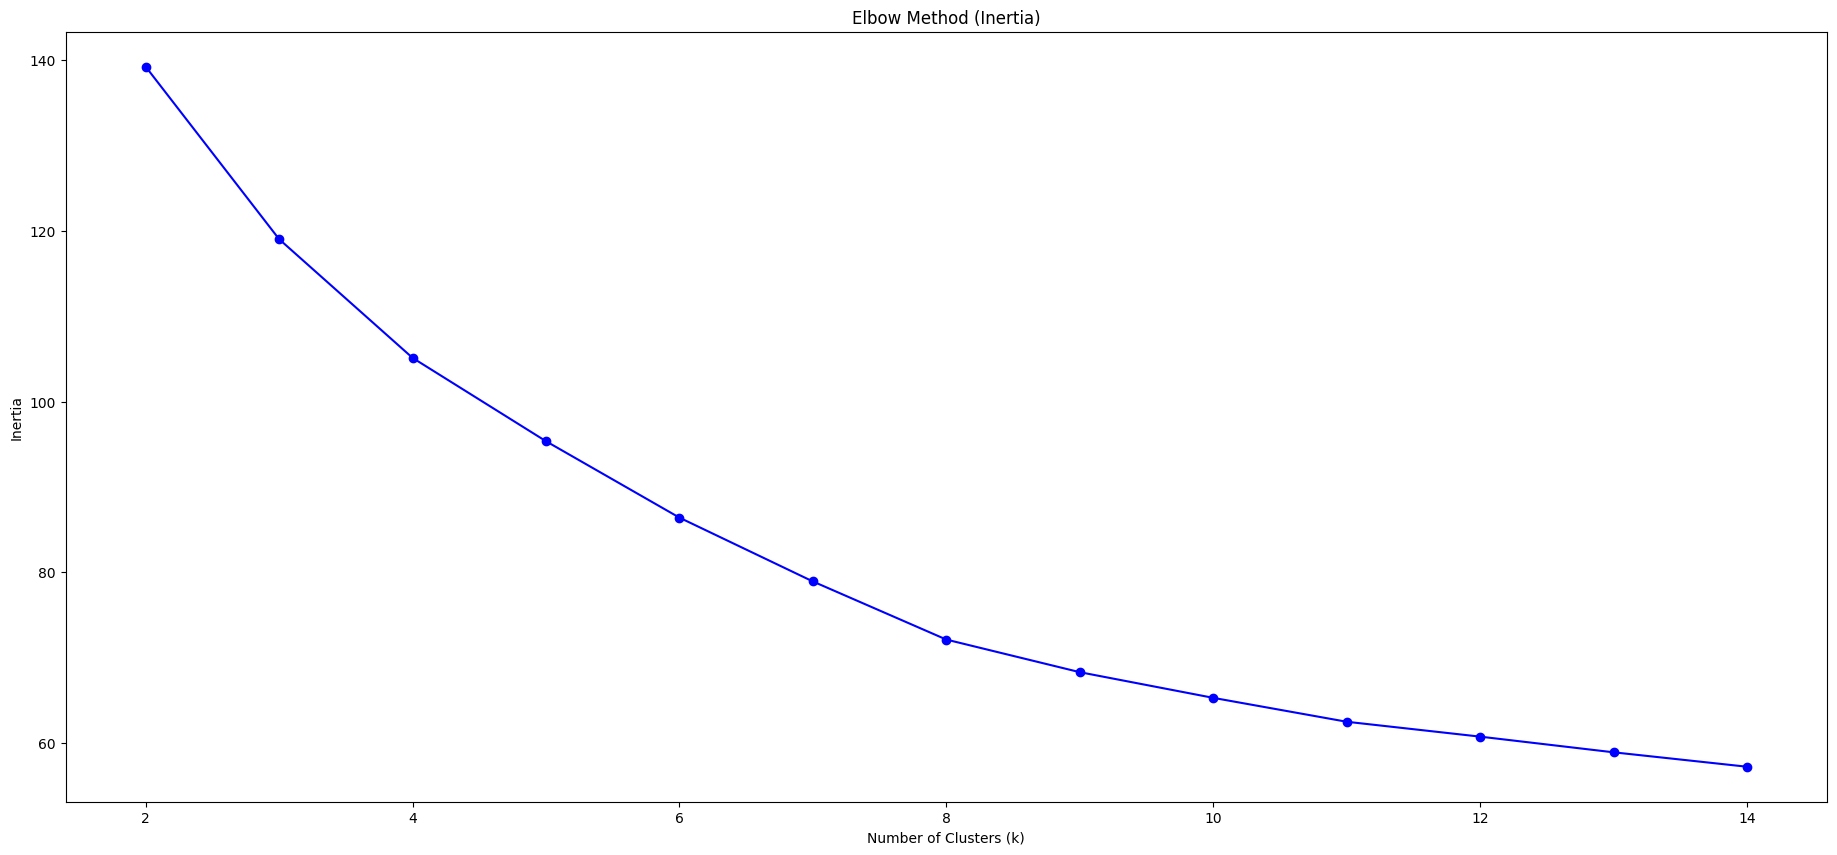

In [146]:
plt.figure(figsize=(50, 10))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', color='b')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

In [147]:
cluster = 2
for score in sil_score:
    print(cluster,score)
    cluster+=1

2 0.4969272309562235
3 0.3128657754161023
4 0.3109676276528631
5 0.32705241875949453
6 0.3506265022389832
7 0.3106424982299354
8 0.3404994194534686
9 0.3120980839894562
10 0.2751511889338219
11 0.2512095343758579
12 0.2528755770858589
13 0.23939866119904263
14 0.2442357164998654


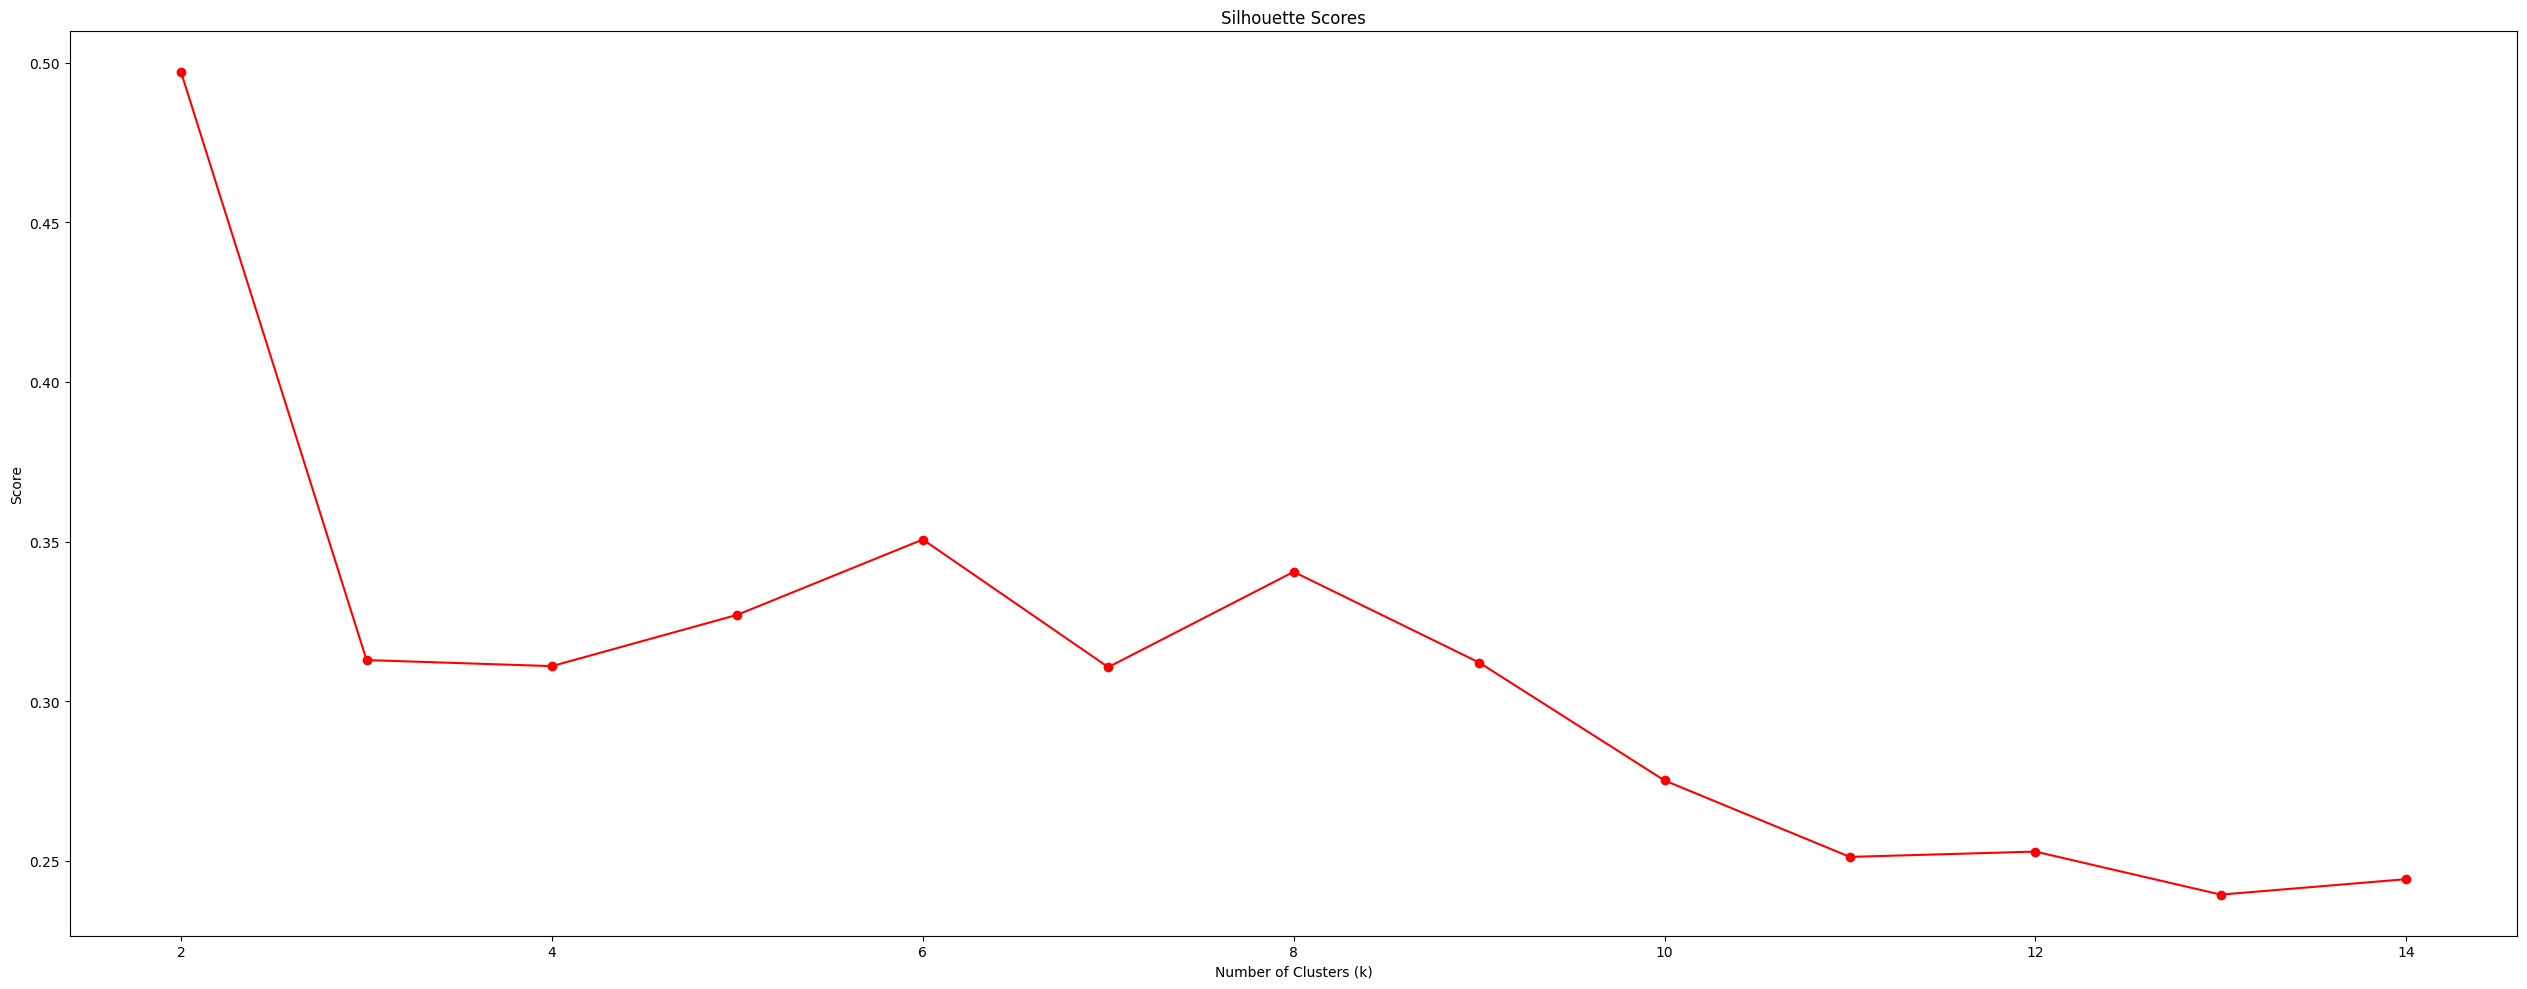

In [148]:
plt.figure(figsize=(50, 10))
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_score, marker='o', color='red')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

In [149]:
k=6
km = KMeans(n_clusters=k,init='k-means++',random_state=42)
km.fit_predict(X)

array([2, 3, 2, ..., 2, 2, 1], shape=(8398,), dtype=int32)

In [150]:
df = pd.DataFrame({
    "tweet": corpus,
    "cluster": km.labels_
})

In [151]:
df.head()

,tweet,cluster
0,"[basically, chat, opened, call, log, message, ...",2
1,"[io, watchos, no, icon, twitter, notification,...",3
2,"[dear, god, not, againapplesupport]",2
3,"[hi, buy, call, duty, wwii, steam, today, inst...",2
4,"[hi, safaricom_care, can't, pay, dstv, text, s...",2


In [152]:
for i in range(k):
    print(f"\nCLUSTER {i}")

    cluster_samples = df[df["cluster"] == i]["tweet"].head(10)

    for tweet in cluster_samples:
        print(tweet)


CLUSTER 0
['idea', 'c', 'operating', 'ba', 'ba', ':)']
['curious', 'nearly', 'every', 'sw', 'flight', 'take', 'fll', 'bwi', 'delayed']
['substitute', 'gluten', 'free', 'food', 'food', 'contains', 'gluten', 'worst', 'home', 'delivery', 'service', 'shop']
['great', 'conductor', 'working', 'c', 'informative', 'well', 'regard', 'handling', 'delay', 'informing', 'everybody', 'travelling']
['lied', 'lifetime', 'price', 'got', 'offer']
['fly', 'lot', 'always', 'love', 'service', 'really', 'stand', 'fly', 'another', 'airline', 'suck']
['need', 'help', 'stuck', 'flight', 'waiting', 'tarmac', 'ord', 'cause', 'maintenance', 'issue', 'plane', 'gate', 'need', 'make', 'connection', 'flight']
['currently', 'booked', 'dl', 'dl']
['no', 'train', 'blake', 'st', 'since', 'cancelled', 'due', 'no', 'driver', 'train', 'uni', 'missed', 'lecture', 'refund']
['bubby', '’', 'first', 'flight', 'delta', 'favorite', 'airport', 'california', 'dreamin', '’', 'notstaged']

CLUSTER 1
['went', 'wrong', 'airport', 'bes

## DBSCAN

In [153]:
from sklearn.cluster import DBSCAN

In [154]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(X)

In [155]:
db = DBSCAN(eps=0.25,min_samples=15)
labels = db.fit_predict(X_reduced)

In [156]:
if len(np.unique(db.labels_)) > 1:
    print(silhouette_score(X_reduced,labels))
else:
    print(np.nan)

0.8190279656573081


In [157]:
np.unique(db.labels_)

array([-1,  0])

## Visualization

In [158]:
from sklearn.manifold import TSNE

In [159]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_2d = tsne.fit_transform(X)

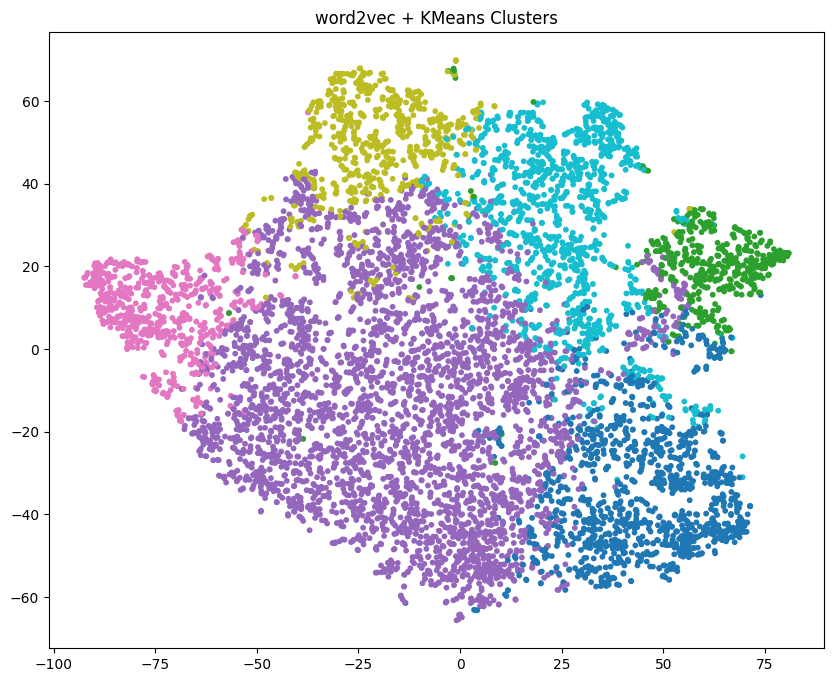

In [160]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=km.labels_,
    cmap='tab10',
    s=10
)

plt.title("word2vec + KMeans Clusters")
plt.show()

In [161]:
cluster_names = {
    0: "Travel & Service",
    1: "Customer Complaints",
    2: "Apps & Telecom",
    3: "Payments & Delivery",
    4: "Account Issues",
    5: "Apple Technical Issues"
}

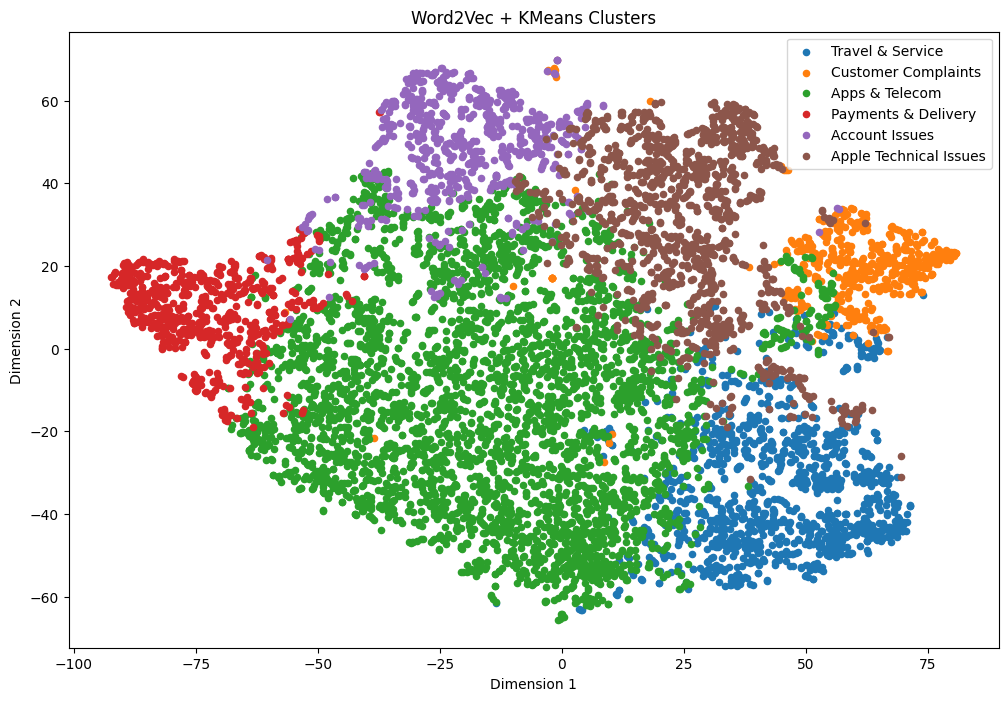

In [163]:
plt.figure(figsize=(12,8))

for cluster_id in np.unique(km.labels_):

    indices = km.labels_ == cluster_id

    plt.scatter(
        X_2d[indices, 0],
        X_2d[indices, 1],
        label=cluster_names[cluster_id],
        s=20
    )

plt.legend()

plt.title("Word2Vec + KMeans Clusters")

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()